In [1]:
import pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

data = pd.read_csv("../data/features.csv")
X = data.drop(columns=["label"])
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(405756, 23) (101440, 23)
label
0    0.774645
1    0.225355
Name: proportion, dtype: float64


In [2]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("Imbalance ratio:", round(ratio, 2))

Imbalance ratio: 3.44


In [3]:
models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced")),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=15, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        scale_pos_weight=ratio, n_jobs=-1, random_state=42,
        eval_metric="logloss"),
}

results, trained = [], {}
for name, model in models.items():
    print("Training", name, "...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })
    trained[name] = model

comparison = pd.DataFrame(results).set_index("Model").round(4).sort_values("F1", ascending=False)
comparison

Training Logistic Regression ...
Training Decision Tree ...
Training Random Forest ...
Training XGBoost ...


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.9165,0.7980,0.8430,0.8199,0.9609
XGBoost,0.9008,0.7363,0.8719,0.7984,0.9619
Decision Tree,0.8676,0.6648,0.8323,0.7392,0.9271
Logistic Regression,0.7980,0.5426,0.6595,0.5954,0.8444


Best model: Random Forest
              precision    recall  f1-score   support

  Legitimate       0.95      0.94      0.95     78580
    Phishing       0.80      0.84      0.82     22860

    accuracy                           0.92    101440
   macro avg       0.88      0.89      0.88    101440
weighted avg       0.92      0.92      0.92    101440



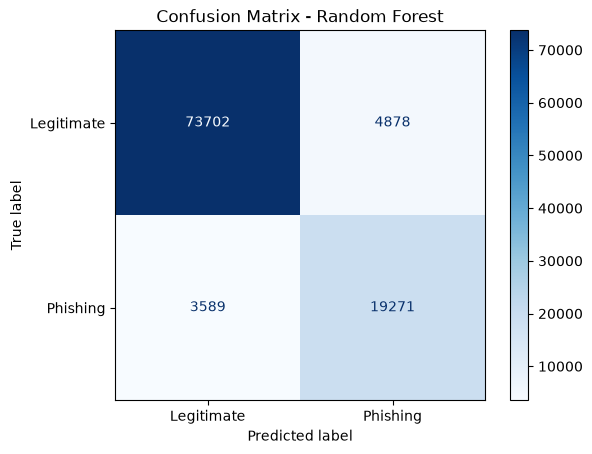

In [4]:
best_name = comparison.index[0]
best = trained[best_name]
print("Best model:", best_name)

pred = best.predict(X_test)
print(classification_report(y_test, pred, target_names=["Legitimate", "Phishing"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["Legitimate", "Phishing"], cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.savefig("../confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

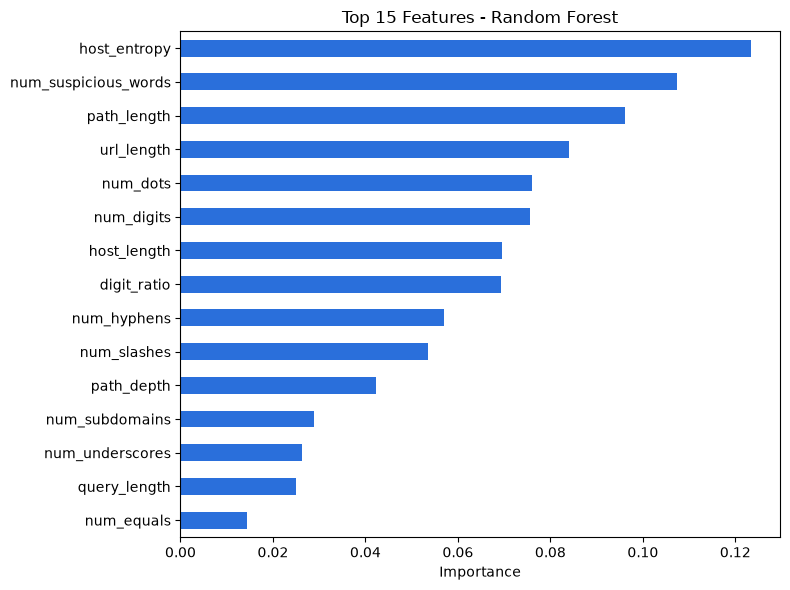

In [5]:
imp = pd.Series(best.feature_importances_, index=X.columns).sort_values()
imp.tail(15).plot(kind="barh", figsize=(8, 6), color="#2a6fdb")
plt.title(f"Top 15 Features - {best_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../feature_importance.png", dpi=150)
plt.show()

In [7]:
joblib.dump(best, "../backend/model.pkl")
joblib.dump(list(X.columns), "../backend/feature_columns.pkl")
comparison.to_csv("../model_comparison.csv")

In [8]:
proba = best.predict_proba(X_test)[:, 1]

for t in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    p = (proba >= t).astype(int)
    false_alarms = int(((p == 1) & (y_test == 0)).sum())
    print(f"threshold {t}: precision {precision_score(y_test, p):.3f} | "
          f"recall {recall_score(y_test, p):.3f} | false alarms {false_alarms}")

threshold 0.4: precision 0.746 | recall 0.879 | false alarms 6837
threshold 0.5: precision 0.796 | recall 0.845 | false alarms 4948
threshold 0.6: precision 0.839 | recall 0.807 | false alarms 3530
threshold 0.7: precision 0.876 | recall 0.766 | false alarms 2473
threshold 0.8: precision 0.915 | recall 0.704 | false alarms 1489
threshold 0.9: precision 0.945 | recall 0.621 | false alarms 830
